# dialing problem

Consider a dialing problem where each step is like the horse (in chess). so 0 can go to either 4 or 6. 6 can go to 0,1,7 etc. (to options for each are provided in a dict).

You need to find the number of optional dialing sequences given a starting number (0-9) and the number of steps

x - starting point
n - number of steps -1
examples: 
- x = 0 , n = 2 - there are two options. 0->4 and 0->6

- x = 6 , n = 2 - there are three options. 6->1, 6->0, 6->7

- x = 0 , n = 3 - 6 options. 0->4->[0,3,9] and 0->4->[0,1,7]

In [1]:
d = {0:[4,6],1:[8,6],2:[7,9],
     3:[4,8],4:[3,9,0],5:[],
     6:[1,7,0],7:[2,6],8:[1,3],9:[4,2]}

In [2]:
def dial(x,n):
    """
    This solves the problem using recursion. 
    however it is not efficient as time is O(n^2) and space is O(n) since it needs to run the function many times on the same time.
    """
    res_tmp = d[x]
    total_numbers = 0
    if n == 1:
        total_numbers = 1 
    else:
        for y in res_tmp:
            total_numbers += dial(y,n-1)
    return total_numbers

In [3]:
caching_d = {(0,1):1}

In [4]:
def dial_cache(x,n):
    """
    This solves the problem using caching.
    first it checks if the result is already in the cache. if it is, it returns the result.
    if not it calculates the result and adds it to the cache.
    """
    if (x,n) in caching_d.keys():
        return caching_d[(x,n)]
    res_tmp = d[x]
    total_numbers = 0
    if n == 1:
        total_numbers = 1 
    else:
        for y in res_tmp:
            total_numbers += dial_cache(y,n-1)
    caching_d[x,n] = total_numbers
    return total_numbers

In [19]:
dial(7,10)

1424

In [20]:
dial_cache(7,10)

1424

# check time efficiency

One can see that as the number of steps rise, the regular function takes more and more time, while the cache is the same time.

In [16]:
import time
t0 = []
t_cache = []
for n in range(1,23):
    print(n)
    start = time.time()
    _ = dial(7,n)
    end = time.time()
    t0.append(end-start)
    print(t0[-1])
    #
    start = time.time()
    _ = dial_cache(7,n)
    end = time.time()
    t_cache.append(end-start)
    print(t_cache[-1])

1
1.4066696166992188e-05
4.76837158203125e-06
2
1.9073486328125e-06
9.5367431640625e-07
3
7.152557373046875e-07
9.5367431640625e-07
4
2.1457672119140625e-06
0.0
5
3.814697265625e-06
0.0
6
5.9604644775390625e-06
9.5367431640625e-07
7
1.5020370483398438e-05
0.0
8
3.0994415283203125e-05
1.1920928955078125e-06
9
7.486343383789062e-05
9.5367431640625e-07
10
0.00015592575073242188
4.76837158203125e-06
11
0.0003688335418701172
9.5367431640625e-07
12
0.0008027553558349609
9.5367431640625e-07
13
0.0019598007202148438
7.152557373046875e-07
14
0.00433802604675293
2.1457672119140625e-06
15
0.010421991348266602
1.9073486328125e-06
16
0.02421283721923828
2.86102294921875e-06
17
0.05969381332397461
2.86102294921875e-06
18
0.11343002319335938
1.9073486328125e-06
19
0.2748880386352539
2.1457672119140625e-06
20
0.5777537822723389
9.059906005859375e-06
21
1.4194798469543457
2.1457672119140625e-06
22
3.1221249103546143
1.5735626220703125e-05


In [17]:
import matplotlib.pyplot as plt

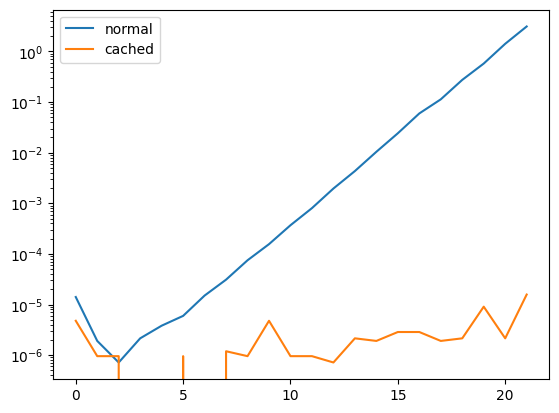

In [18]:
plt.plot(t0,label='normal')
plt.plot(t_cache,label='cached')
plt.yscale('log')
plt.legend()